# 02 — Scene selection: SCL cloud/shadow + haze filtering

Takes the 657-scene, AOI-tightened list from `01_data_prep.ipynb` and refines it using actual raster data:

1. Per-scene **SCL cloud/shadow/cirrus/snow fraction**, computed only within the Ghana boundary (not the whole granule — the `eo:cloud_cover` metadata used in notebook 1 covers the whole tile, which is often misleading).
2. A **Harmattan haze indicator** (blue-band reflectance, compared per-tile) — haze isn't flagged by SCL at all.
3. For each MGRS tile and each month in the dry-season window, keep only the single best (least cloud/shadow) scene, so the final training set has clean, temporally-spread coverage.

All raster reads here are *decimated* (via COG overviews, see `s2sr.raster.read_band_decimated`) — cheap enough to run over hundreds of scenes without downloading full-resolution imagery. Full-resolution reads only happen later, in patch extraction, and only for the scenes selected here.

See `agents.md` "Patch sampling strategy" for the reasoning.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.auto import tqdm

# repo root is the parent of this notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent / "src"))

from s2sr import config, quality, stac

c:\Users\zutad\miniconda3\envs\s2_dsen2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
scenes = gpd.read_file(config.REPO_ROOT / "data" / "interim" / "s2_scenes_ghana_2025_dry_season.geojson")
len(scenes)

657

In [4]:
# Re-search rather than reuse notebook 1's `items`: signed asset URLs expire, and this notebook
# should be runnable on a fresh kernel without depending on another notebook's live state.
items = stac.search_scenes()
items_by_id = {item.id: item for item in items}

missing = set(scenes["id"]) - set(items_by_id)
print(f"{len(scenes)} scenes loaded, {len(missing)} missing from a fresh search (should normally be 0)")

657 scenes loaded, 0 missing from a fresh search (should normally be 0)


In [5]:
# Already cached by notebook 1 — no need to hit Nominatim again.
ghana_boundary = gpd.read_file(config.GHANA_BOUNDARY_PATH)

## Sanity check on a small sample first

The full assessment below reads two decimated bands (SCL + B02) per scene over the network — a few hundred remote reads. Before committing to that, run it on 10 random scenes first and eyeball the results (values should be roughly 0–1 for `cloud_shadow_fraction`, plausible surface-reflectance-ish magnitudes for `blue_mean`, no exceptions).

In [6]:
sample = scenes.sample(10, random_state=0)
sample_records = []
for _, row in tqdm(sample.iterrows(), total=len(sample)):
    item = items_by_id[row["id"]]
    scl_stats = quality.scl_stats(item, ghana_boundary)
    sample_records.append(
        {
            "id": row["id"],
            "mgrs_tile": row["mgrs_tile"],
            "cloud_shadow_fraction": scl_stats["cloud_shadow_fraction"],
            "nodata_fraction": scl_stats["nodata_fraction"],
            "blue_mean": quality.blue_reflectance_in_aoi(item, ghana_boundary),
        }
    )
pd.DataFrame(sample_records)

100%|██████████| 10/10 [00:20<00:00,  2.08s/it]


,id,mgrs_tile,cloud_shadow_fraction,nodata_fraction,blue_mean
0,S2B_MSIL2A_20250301T101849_R065_T30PZT_2025030...,30PZT,0.842841,0.000000,2542.278231
1,S2A_MSIL2A_20250112T101401_R022_T30PZR_2025011...,30PZR,0.007229,0.945415,1441.871645
2,S2C_MSIL2A_20250227T103021_R108_T30NVP_2025022...,30NVP,0.093910,0.000000,1400.977990
3,S2A_MSIL2A_20250321T102731_R108_T30PWR_2025032...,30PWR,0.125702,0.180713,1711.548371
4,S2C_MSIL2A_20250405T102041_R065_T30NYL_2025040...,30NYL,0.152028,0.006170,2604.487663
5,S2A_MSIL2A_20250115T102351_R065_T30NZL_2025011...,30NZL,0.014851,0.580332,1091.490164
6,S2C_MSIL2A_20250309T102911_R108_T30PXQ_2025030...,30PXQ,0.041218,0.924850,1274.285142
7,S2B_MSIL2A_20250120T102239_R065_T30PZT_2025012...,30PZT,0.000166,0.000000,1812.461001
8,S2C_MSIL2A_20250224T102051_R065_T30PXR_2025022...,30PXR,0.052349,0.064636,1672.902377
9,S2C_MSIL2A_20250316T101821_R065_T30PZQ_2025031...,30PZQ,0.127627,0.128850,1469.980885


## Full assessment

If the sample above looked reasonable, run this over all scenes. This will take a while — grab a coffee. Individual read failures (network hiccups) are caught and skipped rather than aborting the whole run; the failure count is reported at the end.

In [9]:
records = []
failed_ids = []
for _, row in tqdm(scenes.iterrows(), total=len(scenes)):
    item = items_by_id.get(row["id"])
    if item is None:
        failed_ids.append(row["id"])
        continue
    try:
        scl_stats = quality.scl_stats(item, ghana_boundary)
        blue_mean = quality.blue_reflectance_in_aoi(item, ghana_boundary)
    except Exception:
        failed_ids.append(row["id"])
        continue
    records.append(
        {
            "id": row["id"],
            "cloud_shadow_fraction": scl_stats["cloud_shadow_fraction"],
            "nodata_fraction": scl_stats["nodata_fraction"],
            "blue_mean": blue_mean,
        }
    )

quality_df = scenes.merge(pd.DataFrame(records), on="id", how="inner")
print(f"Assessed {len(quality_df)} scenes, {len(failed_ids)} failed reads (skipped)")

100%|██████████| 657/657 [04:58<00:00,  2.20it/s]

Assessed 657 scenes, 0 failed reads (skipped)


In [11]:
# Checkpoint: the expensive part is done, so save it — thresholds below can be retuned without
# re-running the raster loop.
checkpoint_path = config.REPO_ROOT / "data" / "interim" / "s2_scenes_ghana_2025_quality.geojson"
quality_df.to_file(checkpoint_path, driver="GeoJSON")
checkpoint_path

WindowsPath('C:/Users/zutad/Desktop/work_folder/s2_dsen2/data/interim/s2_scenes_ghana_2025_quality.geojson')

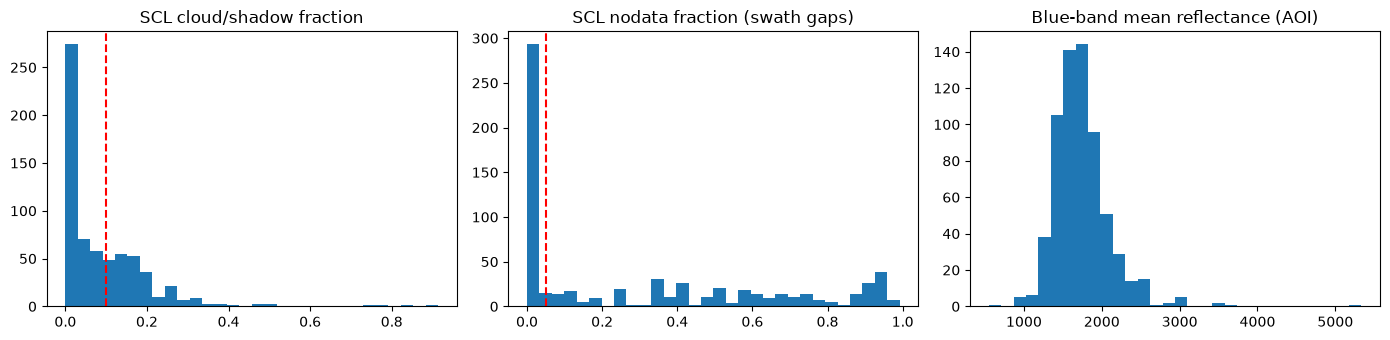

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.5))
axes[0].hist(quality_df["cloud_shadow_fraction"].dropna(), bins=30)
axes[0].axvline(config.MAX_SCL_CLOUD_SHADOW_FRACTION, color="red", linestyle="--")
axes[0].set_title("SCL cloud/shadow fraction")
axes[1].hist(quality_df["nodata_fraction"].dropna(), bins=30)
axes[1].axvline(config.MAX_SCL_NODATA_FRACTION, color="red", linestyle="--")
axes[1].set_title("SCL nodata fraction (swath gaps)")
axes[2].hist(quality_df["blue_mean"].dropna(), bins=30)
axes[2].set_title("Blue-band mean reflectance (AOI)")
fig.tight_layout()

## Haze flagging

Compares each scene's blue-band reflectance against its *own tile's* typical value (median/MAD-based modified z-score), rather than a single global cutoff — Harmattan haze shows up as an outlier relative to what that specific tile normally looks like.

In [13]:
quality_df["haze_zscore"] = quality_df.groupby("mgrs_tile")["blue_mean"].transform(quality.haze_modified_zscore)
quality_df["is_haze_outlier"] = quality_df["haze_zscore"] > config.HAZE_ZSCORE_THRESHOLD
quality_df["is_haze_outlier"].value_counts()

is_haze_outlier
False    635
True      22
Name: count, dtype: int64

In [14]:
kept = quality_df[
    (quality_df["cloud_shadow_fraction"] <= config.MAX_SCL_CLOUD_SHADOW_FRACTION)
    & (quality_df["nodata_fraction"] <= config.MAX_SCL_NODATA_FRACTION)
    & (~quality_df["is_haze_outlier"])
].copy()
print(f"After cloud/shadow + nodata + haze filtering: {len(kept)} scenes, {kept['mgrs_tile'].nunique()} tiles")

kept["window"] = pd.to_datetime(kept["datetime"]).dt.tz_localize(None).dt.to_period(config.SELECTION_TIME_WINDOW)
selected = (
    kept.sort_values("cloud_shadow_fraction")
    .groupby(["mgrs_tile", "window"], as_index=False)
    .first()
)
selected = gpd.GeoDataFrame(selected, geometry="geometry", crs=kept.crs)
print(f"Selected: {len(selected)} scenes (best per tile per {config.SELECTION_TIME_WINDOW}-window)")

After cloud/shadow + nodata + haze filtering: 186 scenes, 26 tiles
Selected: 85 scenes (best per tile per M-window)


In [15]:
selected.groupby("mgrs_tile").size().sort_values(ascending=False)

mgrs_tile
30PWS    5
30PWR    5
30PYT    5
30PXQ    5
30PZT    5
30PWT    4
30NZL    4
30PYR    4
30NYP    4
30NXP    4
30PYS    4
30PZS    4
31PBL    4
31PBM    4
30PYQ    4
30PZR    3
30NVP    2
30NXM    2
30NYM    2
31NBG    2
31NBJ    2
30NYN    2
31NBH    2
30PWQ    1
30NXN    1
30NZM    1
dtype: int64

In [16]:
out_path = config.REPO_ROOT / "data" / "interim" / "s2_scenes_ghana_2025_selected.geojson"
selected.drop(columns="window").to_file(out_path, driver="GeoJSON")
out_path

WindowsPath('C:/Users/zutad/Desktop/work_folder/s2_dsen2/data/interim/s2_scenes_ghana_2025_selected.geojson')

## Eyeball check

Quick visual sanity check before trusting the filters: true-color previews of the scenes with the *highest* blue reflectance among those that made the final cut (most haze-suspect survivors) plus a couple of the clearest for contrast. If any of the "high blue" ones visibly look hazy despite passing both filters, the thresholds need tightening.

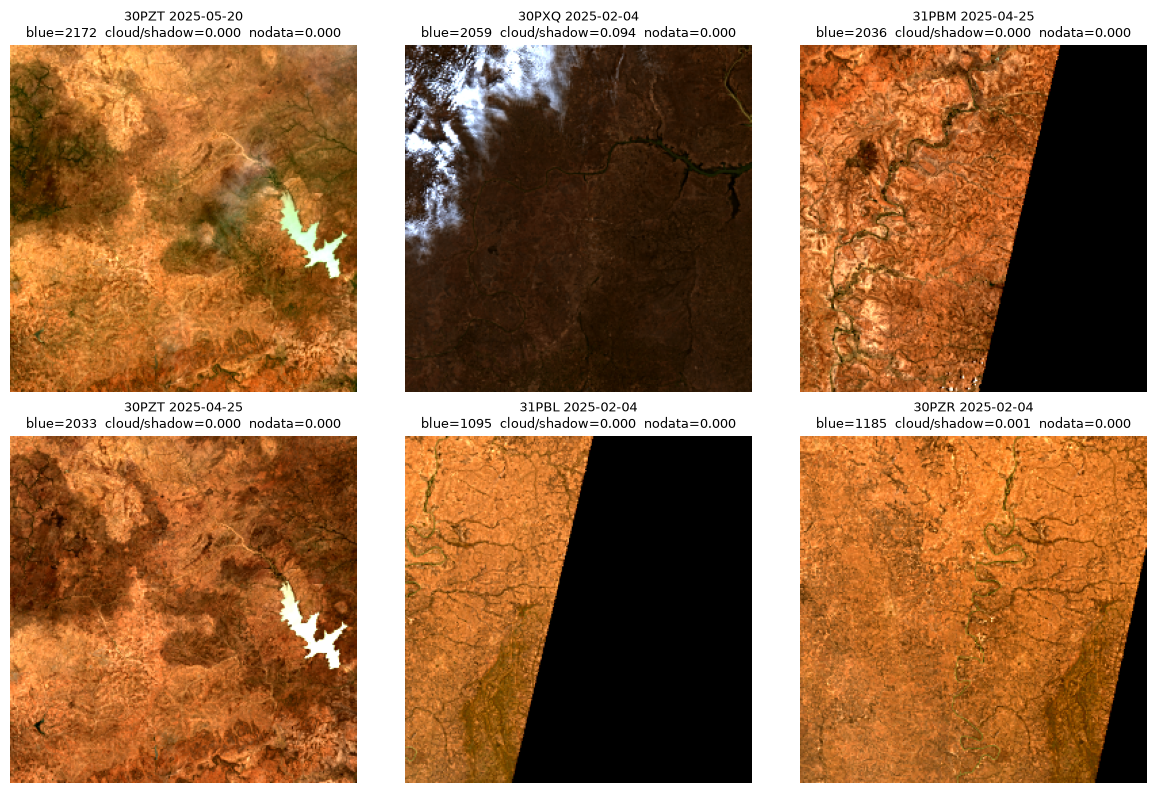

In [17]:
from s2sr import raster

eyeball_sample = pd.concat(
    [
        selected.sort_values("blue_mean", ascending=False).head(4),
        selected.sort_values("blue_mean", ascending=True).head(2),
    ]
)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (_, row) in zip(axes.flat, eyeball_sample.iterrows()):
    item = items_by_id[row["id"]]
    rgb = raster.read_rgb_preview(item)
    ax.imshow(rgb)
    date_str = pd.to_datetime(row["datetime"]).strftime("%Y-%m-%d")
    ax.set_title(
        f"{row['mgrs_tile']} {date_str}\n"
        f"blue={row['blue_mean']:.0f}  cloud/shadow={row['cloud_shadow_fraction']:.3f}  "
        f"nodata={row['nodata_fraction']:.3f}",
        fontsize=9,
    )
    ax.axis("off")
fig.tight_layout()

## Next steps

- Inspect the histograms and per-tile counts above — retune `MAX_SCL_CLOUD_SHADOW_FRACTION` / `HAZE_ZSCORE_THRESHOLD` / `SELECTION_TIME_WINDOW` in `s2sr/config.py` if the selected set looks too sparse or too permissive, then re-run from the `filter-and-select` cell (no need to redo the expensive raster loop — it's checkpointed).
- Notebook 3: land-cover stratification and patch extraction (Wald's protocol) over this selected scene list.